<!-- EDA -->

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# now let's start the analysis B4 create the ML model:

## 1. EDA

In [42]:
df.shape

(1338, 7)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [44]:
df.describe()
# It shows various calculations of all the numeric columns...

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [45]:
# to check whether there are any null values or not in the dataset...
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [46]:
# what are the columns present in the dataframe...
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

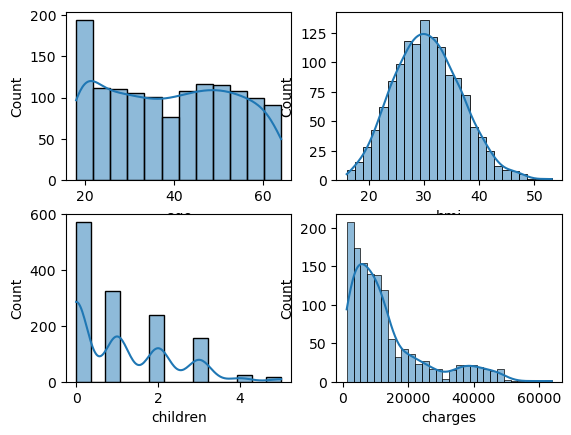

In [47]:
# now let's create some plots regarding numeric values for better understanding the data relation

#from chatGPT!! 
# ............................................
# num_cols = ['age','bmi','children','charges']
# cat_cols = ['sex','smoker','region']
# import seaborn as sns
# plt.figure(figsize=(12,8))
# for i, col in enumerate(num_cols, 1):
#     plt.subplot(2, 2, i)
#     sns.histplot(df[col], kde=True)
#     plt.title(f'Distribution of {col}')

# plt.tight_layout()
# plt.show()
# ................................................*******************************)
#? This method is perfect:

# numeric_columns = ['age','bmi','children','charges']
# for col in numeric_columns:
#     plt.figure(figsize = (6,4))
#     sns.histplot(df[col],kde=True,bins=20)
# def plotting(var,num):
#     plt.subplot(2,2,num)
#     sns.histplot(df[var],kde=True)
# ................................................*******************************)
plotting('age',1)
plotting('bmi',2)
plotting('children',3)
plotting('charges',4)

<Axes: xlabel='children', ylabel='count'>

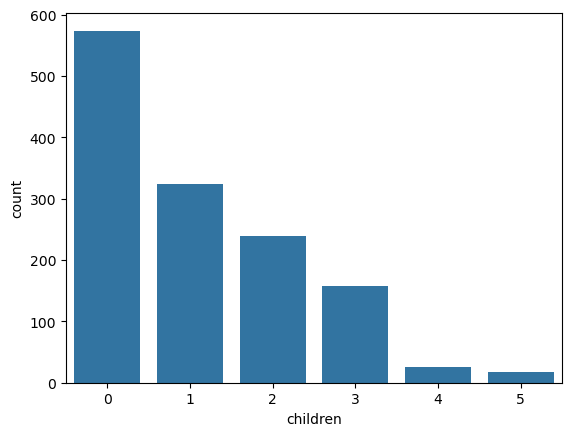

In [48]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

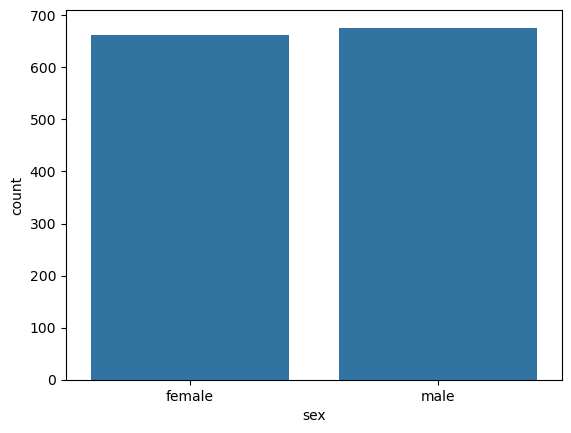

In [49]:
sns.countplot(x = df['sex'])


<Axes: xlabel='smoker', ylabel='count'>

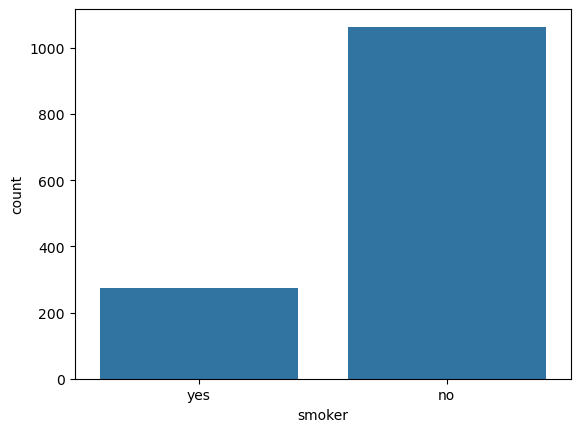

In [50]:
sns.countplot(x = df['smoker'])

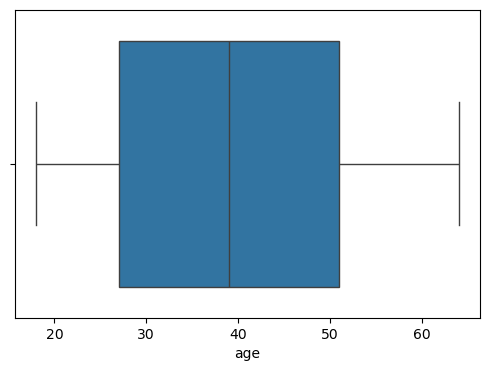

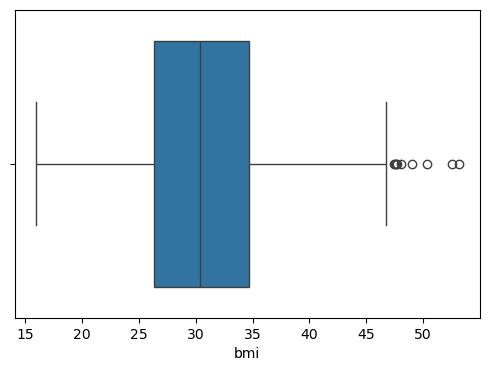

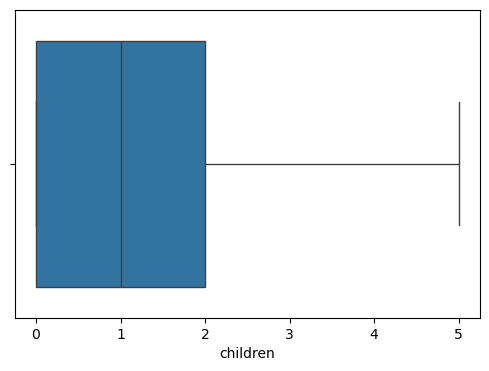

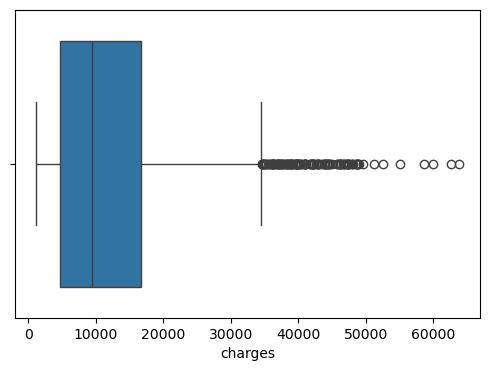

In [51]:
# making boxplot to know about the outliers...
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x =df[col])

<Axes: >

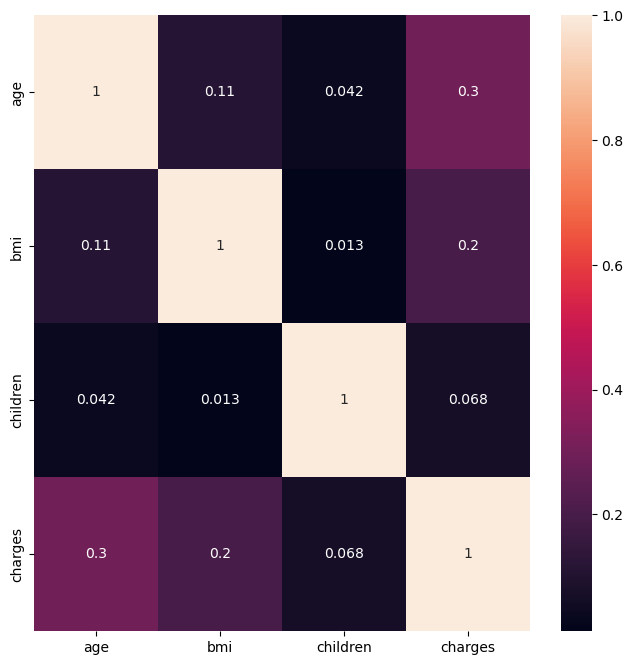

In [52]:
# now checking the correlation using heatmap...
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
# finding the correlation among the numeric columns 

In [53]:
# from the plot we can see which boxes are present near 1 that are strongly in relation...
# other values that are near 0 are in weak relation...don't help in ML model ig

# 2.Data Cleaning and preprocessing

In [54]:
# now we have to clean the data and then have to process it but 
# The data we have taken is already cleaned there are no issues ...
df_cleaned = df.copy()
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [55]:
df_cleaned.shape

(1338, 7)

In [56]:
# removing duplicates...
df_cleaned.drop_duplicates(inplace= True)
# remember we have to write "inplace = True" then only it will save permanently ..

In [57]:
df_cleaned.shape

(1337, 7)

In [58]:
# is there any null values or not...
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [59]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [60]:
# now our target is to make all the data in numeric form except charges//
df_cleaned['sex']= df_cleaned['sex'].map({'male':0,'female':1})

In [61]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [62]:
df_cleaned['smoker'].value_counts()
# It's necessary all the time when we will be going to convert the categorical data to numeric data
# coz then only we will know how many values there are..


smoker
no     1063
yes     274
Name: count, dtype: int64

In [63]:
df_cleaned['smoker']= df_cleaned['smoker'].map({'no':0,'yes':1}) 
# binary encoding / dummy encoding
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [64]:
df_cleaned.rename(columns={
    'sex' :'is_female',
    'smoker': 'is_smoker'
                          },inplace = True)

In [65]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [66]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [67]:
# there are 4 types of variable so we have to use "ONE HOT decoding"...
pd.get_dummies(df['region'])
# by this single code, we will get all four cols separately with the value "true", "false"

,northeast,northwest,southeast,southwest
0,False,False,False,True
1,False,False,True,False
2,False,False,True,False
3,False,True,False,False
4,False,True,False,False
...,...,...,...,...
1333,False,True,False,False
1334,True,False,False,False
1335,False,False,True,False
1336,False,False,False,True


In [68]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [69]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'],drop_first = True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [70]:
df_cleaned = df_cleaned.astype(int)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


In [71]:
# now our data almost readyyy...

# 3 Feature Engineering and Extraction

In [72]:
# in this section, we can make more columns to help the model increase accuracy. 
# & will see the plots...

<Axes: xlabel='bmi', ylabel='Count'>

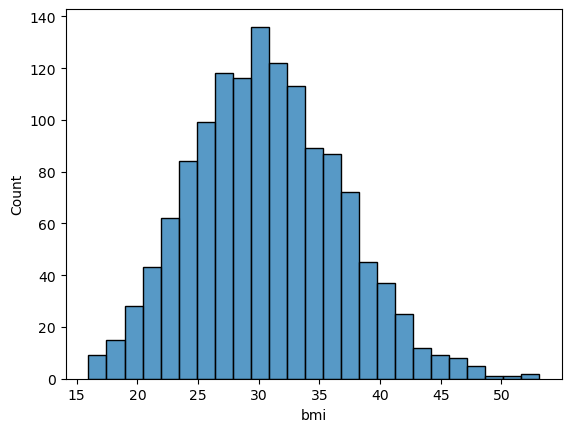

In [73]:
sns.histplot(df['bmi'])

In [74]:
# let's create the bins..
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0,18.5,24.9,29.9,float('inf')],
# here the written data is taken from Google, we need research to get info
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [75]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [76]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['bmi_category'],drop_first=True)
# pd.get_dummies() converts it into binary (0/1)
# Keep (n − 1) columns for n categories using "drop_first=True"
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [77]:
# now we will play with statistics and ...

In [78]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

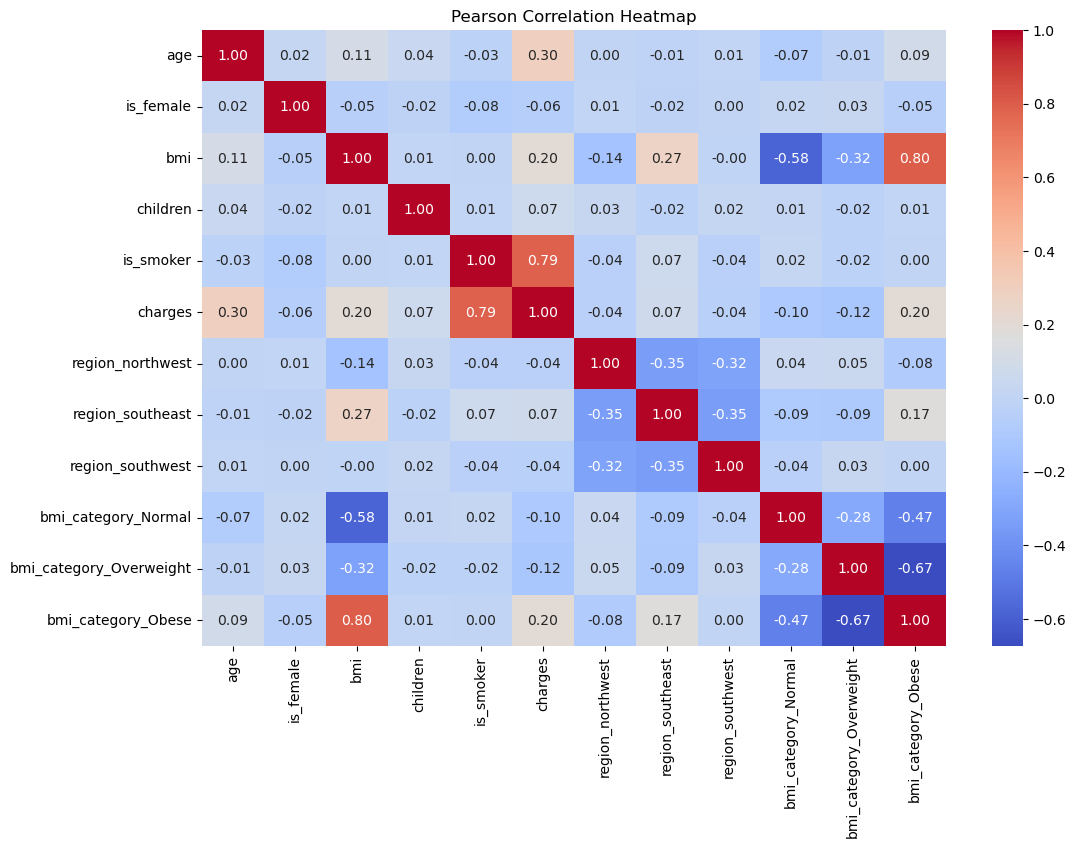

In [79]:
# Pearson Correlation Matrix (All features)
corr_matrix = df_cleaned.corr(method='pearson')

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()
# I used Pearson correlation on the cleaned numerical dataset to measure
# linear relationships and identify important features affecting insurance charges.

In [80]:
# Pearson Correlation with Target (charges) 🔥
corr_with_charges = (
    df_cleaned
    .corr(method='pearson')['charges']
    .sort_values(ascending=False)
)

corr_with_charges

charges                    1.000000
is_smoker                  0.787234
age                        0.298309
bmi_category_Obese         0.200348
bmi                        0.196236
region_southeast           0.073577
children                   0.067390
region_northwest          -0.038695
region_southwest          -0.043637
is_female                 -0.058046
bmi_category_Normal       -0.104042
bmi_category_Overweight   -0.120601
Name: charges, dtype: float64

In [81]:
# Keep only important features (Optional)
important_features = corr_with_charges[abs(corr_with_charges) > 0.2]
important_features


charges               1.000000
is_smoker             0.787234
age                   0.298309
bmi_category_Obese    0.200348
Name: charges, dtype: float64

In [82]:
# #? r value	Meaning
# +1	Strong positive
# -1	Strong negative
# 0	No linear relation
# > 0.5	Strong
# 0.3 – 0.5	Moderate
# < 0.2	Weak

In [83]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [84]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])
# it is basically turning the data in the range between -3 to +3

In [85]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [86]:
# now to check “Which features have a strong linear relationship with insurance charges?”
# Pearson correlation is used when:
#1. Both variables are numeric
#2. You want to measure linear relationship


from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_Obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_Normal,-0.104042


In [87]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]
# removing region_northwest...useless coz -0.03

# ....................................................................................
#   Test	         Used for
# Correlation	numeric ↔ numeric
# Chi-square	categorical ↔ categorical


# here we already got the relation btwn charges and numeric cols,,,now to see the relation btwn 
# # charges (numeric) & cat_features

# Chi-square test is used to check the association between two categorical variables. 
# Since insurance charges are continuous,
# they are converted into categories using charges_bin to make the test applicable.

In [88]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
# We have to create bins to convert numeric data to categorical data...

chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [89]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]


In [90]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


In [91]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [92]:
from sklearn.model_selection import train_test_split

In [93]:
x = final_df.drop('charges',axis=1)
y = final_df['charges']

In [94]:
x_train, x_test = train_test_split(x, test_size=0.2)
y_train, y_test = train_test_split(y, test_size=0.2)


In [95]:
from sklearn.linear_model import LinearRegression

In [96]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [97]:
y_pred = model.predict(x_test)

In [98]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
r2
n = x_test.shape[0]
p = x_test.shape[1]
adjusted_r2 = 1 - ((1-r2)*(n-1) / (n-p-1))
adjusted_r2

-0.056174884427036886